# THREE CLASSES/GENRE , latin, electronic, pop

# Spotify Genre Classification

This project will guide you through the process of building a music genre classifier. You’ll start by selecting specific genres to work with, then examine correlations among different musical features. Using these correlations, you'll identify any redundant features that could be removed to improve model performance and simplify the dataset.

After preparing your data, you’ll train and evaluate three different classification models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. By the end of this project, you’ll compare these models to see which performs best in classifying music genres.

Let’s get started and see how well machine learning can predict the genre of a song based on its characteristics!

## Import Libraries

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load and Explore Dataset
It’s essential to load and explore your dataset to understand its structure, identify any missing or inconsistent values, and get a sense of the types of features available. This initial exploration helps you make informed decisions about data cleaning, feature selection, and preprocessing steps.

In [23]:
# Load the dataset
df = pd.read_csv('dataset.csv')

# Display initial dataset information
print("First 5 rows of the dataset:")
print(df.head(5))
print("\nInitial Data Overview:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 rows of the dataset:
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          

## Select Genres

For this project, you’ll conduct three classification experiments. One experiment should be binary (classifying between two genres), while the other two will be multiclass (classifying among multiple genres).

Choose Your Genres
Below are some genre options available in the dataset:

`['rock', 'rap', 'jazz', 'latin', 'country', 'pop', 'classical', 'electronic', 'acoustic', 'r-and-b']`

Feel free to explore the dataset if you'd like to use other genres, this dataset has over 100 genres available!

#Instructions
**Binary Experiment:** Choose two genres that you want to classify between (e.g., Rock vs. Jazz). This experiment will help you understand classification when only two classes are present.

**Multiclass Experiments:** For the other two experiments, choose three or more genres to create multiclass classification problems (e.g., Rock, Pop, and Classical). These experiments will show how classification models perform with more categories.



In [24]:
# Example: selected_genres = ['rock', 'rap', 'jazz', 'latin', 'country', 'pop']
selected_genres = ['latin','electronic','pop']  # <- Enter your genres here

# Filter for the selected genres
df = df[df['track_genre'].isin(selected_genres)]

# Limit the dataset to a sample of 100 tracks per selected genre
df = df.groupby('track_genre').apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)

/var/folders/5m/lm5s5llx2ml81msrkdfrhm_h0000gn/T/ipykernel_41449/1180617880.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('track_genre').apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)


In [25]:
df['track_genre'].value_counts()
df['track_genre'].unique()


array(['electronic', 'latin', 'pop'], dtype=object)

In [26]:
df['track_genre'].value_counts()

track_genre
electronic    100
latin         100
pop           100
Name: count, dtype: int64

## Data Cleaning and Preparation

Preparing data for machine learning involves selecting relevant columns, handling missing values, and encoding categorical variables. First, selecting only the most relevant columns focuses the dataset on essential features, simplifying the model and often improving performance. Next, handling missing values is crucial because incomplete data can disrupt model training; we address this by either removing rows with missing entries or filling them in with appropriate values, such as the mean or median. Finally, encoding categorical variables (like genre) into numerical format allows machine learning algorithms to process non-numeric data. By assigning a unique number to each category using label encoding, we enable the model to interpret these variables accurately, making our dataset ready for analysis.


In [27]:
# Select relevant columns
df = df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
         'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'explicit', 'track_genre']]

# Drop any rows with missing values
df.dropna(inplace=True)

# Convert 'track_genre' to numerical values (Label Encoding)
label_encoder = LabelEncoder()
df['track_genre'] = label_encoder.fit_transform(df['track_genre'])

# Convert 'explicit' to binary 1/0
df['explicit'] = df['explicit'].astype(int)

# Show class distribution for genres after filtering and sampling
print("\nSampled Genre Distribution:")
print(df['track_genre'].value_counts())


Sampled Genre Distribution:
track_genre
0    100
1    100
2    100
Name: count, dtype: int64


## Correlation Analysis

The heatmap above shows correlations between features in the dataset. High correlation values (close to 1 or -1) indicate features that likely carry similar information. Removing one of these correlated features can reduce the dataset’s dimensionality, making the model simpler and potentially improving performance.



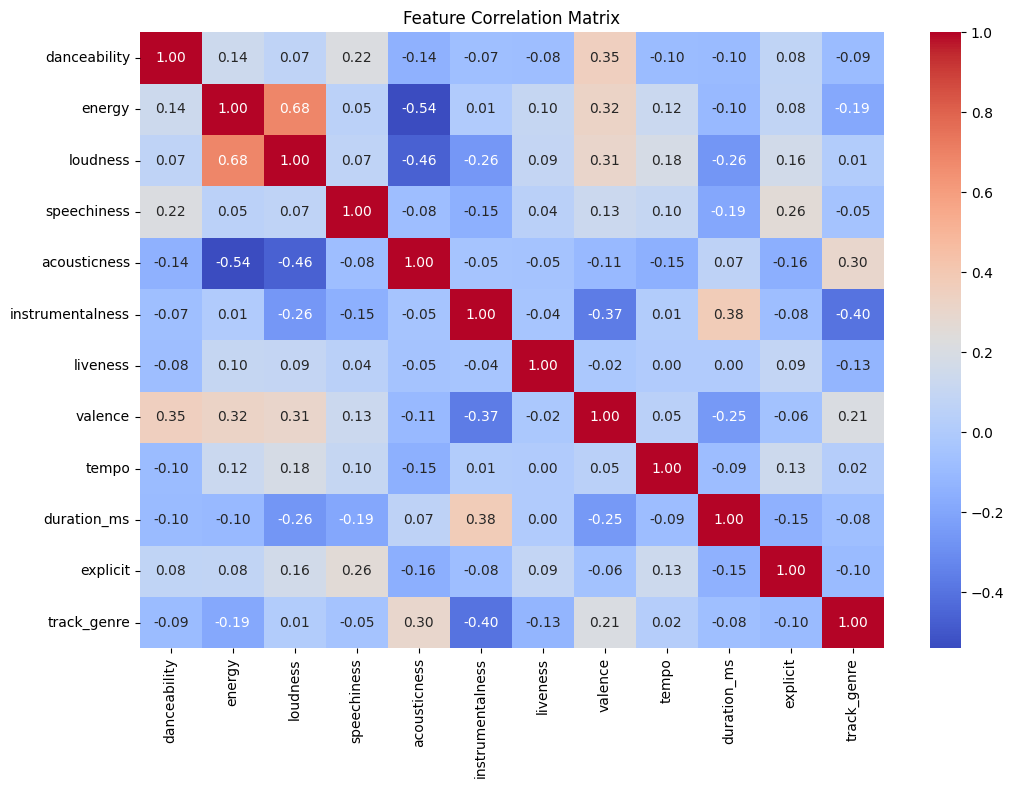

In [28]:

# Heatmap Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()



## Feature Selection Experiments
**Experiment 1: Train with all features**
Train your models (SVM, KNN, and Random Forest) using all features to establish a baseline. You can do this by running the rest of the notebook without making any changes.

**Experiment 2: Remove one highly correlated feature**
Identify a pair of features with a correlation around |0.7| or higher, then remove one and re-train your models. Note any differences compared to the baseline.

**Experiment 3: Remove multiple correlated features**
Remove multiple features with correlations around |0.7| or higher. Re-train your models and compare these results with both the baseline and Experiment 2.

These experiments will help you understand the impact of correlated features on model performance.

In [29]:
# Example: remove_features = ['danceability', 'liveness', 'speechiness', 'instrumentalness', 'duration_ms']
remove_features = []  # <- Enter  features to remove here

# Drop the selected features
df.drop(columns=remove_features, inplace=True)

# Part B Experiment 1 with all features 

## Prepare Data for Modeling

Split the data into training and testing sets and standardize the features.

In [30]:
# Feature and target selection
X = df.drop(columns=['track_genre'])
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Train and evaluate three models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. Compare their accuracies to find the best-performing model.

In [31]:
# 1. Support Vector Machine (SVM)
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.6222222222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.60      0.68        35
           1       0.55      0.64      0.59        28
           2       0.57      0.63      0.60        27

    accuracy                           0.62        90
   macro avg       0.63      0.62      0.62        90
weighted avg       0.64      0.62      0.63        90

Confusion Matrix:
 [[21  6  8]
 [ 5 18  5]
 [ 1  9 17]]


In [32]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.5666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.63      0.64        35
           1       0.45      0.50      0.47        28
           2       0.60      0.56      0.58        27

    accuracy                           0.57        90
   macro avg       0.57      0.56      0.56        90
weighted avg       0.57      0.57      0.57        90

Confusion Matrix:
 [[22  9  4]
 [ 8 14  6]
 [ 4  8 15]]


In [33]:
# 3. Random Forest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.6333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75        35
           1       0.59      0.71      0.65        28
           2       0.50      0.41      0.45        27

    accuracy                           0.63        90
   macro avg       0.62      0.62      0.62        90
weighted avg       0.63      0.63      0.63        90

Confusion Matrix:
 [[26  3  6]
 [ 3 20  5]
 [ 5 11 11]]


## Model Comparison

Compare model accuracies to determine the best model for genre classification.

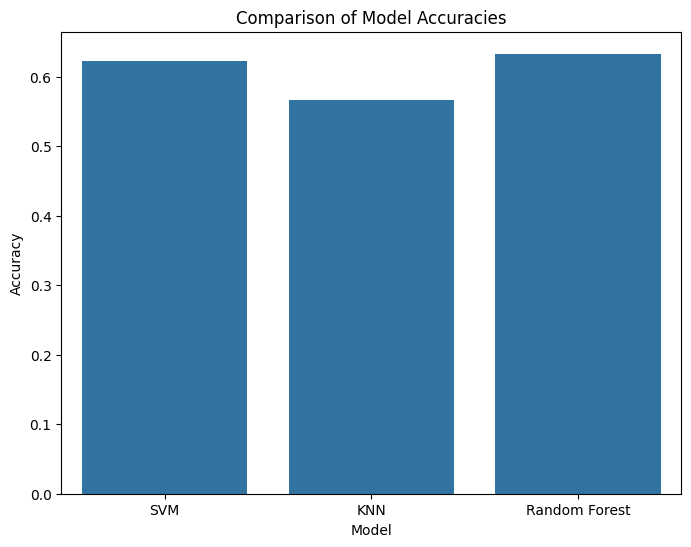

In [34]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

## Summary

Analyze the model performances and select the model with the highest accuracy for this genre classification task.

 # Part B Experiment 2 removing acousticness feature


In [35]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.807,0.812,-5.009,0.1060,0.00773,0.000501,0.2360,0.2420,128.012,171799,1,0
1,0.736,0.401,-11.285,0.0476,0.10200,0.293000,0.0938,0.0543,100.008,453506,0,0
2,0.640,0.533,-8.951,0.0417,0.08670,0.240000,0.1700,0.1760,103.027,200389,0,0
3,0.763,0.414,-11.165,0.0845,0.08290,0.637000,0.0552,0.4980,125.000,187684,0,0
4,0.653,0.496,-7.262,0.0868,0.62500,0.274000,0.1510,0.1020,86.013,195905,1,0


In [36]:
# Feature and target selection
X = df.drop(columns=['track_genre','acousticness'])
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
#svm 
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.5888888888888889
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.54      0.62        35
           1       0.58      0.64      0.61        28
           2       0.48      0.59      0.53        27

    accuracy                           0.59        90
   macro avg       0.60      0.59      0.59        90
weighted avg       0.61      0.59      0.59        90

Confusion Matrix:
 [[19  5 11]
 [ 4 18  6]
 [ 3  8 16]]


In [38]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.5777777777777777
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.63      0.63        35
           1       0.47      0.50      0.48        28
           2       0.64      0.59      0.62        27

    accuracy                           0.58        90
   macro avg       0.58      0.57      0.58        90
weighted avg       0.58      0.58      0.58        90

Confusion Matrix:
 [[22  9  4]
 [ 9 14  5]
 [ 4  7 16]]


In [39]:
# random forrest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.6222222222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.66      0.71        35
           1       0.60      0.64      0.62        28
           2       0.50      0.56      0.53        27

    accuracy                           0.62        90
   macro avg       0.62      0.62      0.62        90
weighted avg       0.63      0.62      0.63        90

Confusion Matrix:
 [[23  4  8]
 [ 3 18  7]
 [ 4  8 15]]


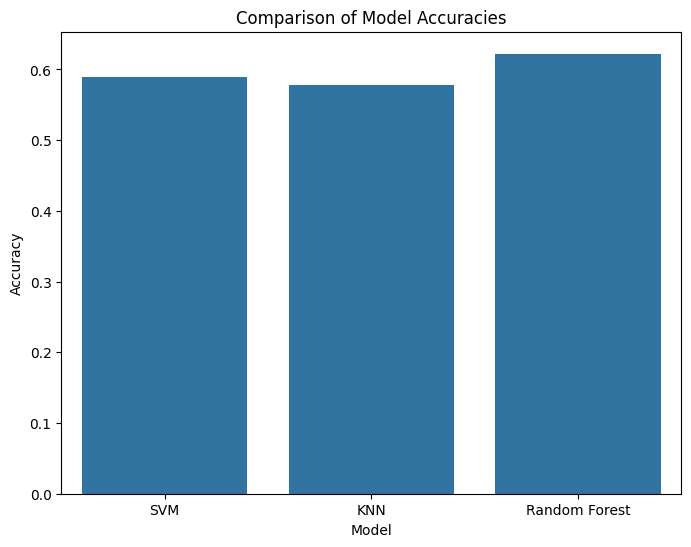

In [40]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

 Dropping the acousticness feature dropped accuracy for all three models by roughly 10 but random forrest wasnt affected as much.it had a slighter decrease

# Part B Experiment 3  Removing features loudness and acousticness

In [41]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.807,0.812,-5.009,0.1060,0.00773,0.000501,0.2360,0.2420,128.012,171799,1,0
1,0.736,0.401,-11.285,0.0476,0.10200,0.293000,0.0938,0.0543,100.008,453506,0,0
2,0.640,0.533,-8.951,0.0417,0.08670,0.240000,0.1700,0.1760,103.027,200389,0,0
3,0.763,0.414,-11.165,0.0845,0.08290,0.637000,0.0552,0.4980,125.000,187684,0,0
4,0.653,0.496,-7.262,0.0868,0.62500,0.274000,0.1510,0.1020,86.013,195905,1,0


In [42]:
# Feature and target selection
X = df.drop(columns=['track_genre','loudness','acousticness'])
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
#svm 
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.6111111111111112
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.57      0.63        35
           1       0.58      0.64      0.61        28
           2       0.55      0.63      0.59        27

    accuracy                           0.61        90
   macro avg       0.61      0.61      0.61        90
weighted avg       0.62      0.61      0.61        90

Confusion Matrix:
 [[20  6  9]
 [ 5 18  5]
 [ 3  7 17]]


In [44]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.6
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.60      0.61        35
           1       0.50      0.54      0.52        28
           2       0.69      0.67      0.68        27

    accuracy                           0.60        90
   macro avg       0.60      0.60      0.60        90
weighted avg       0.60      0.60      0.60        90

Confusion Matrix:
 [[21  9  5]
 [10 15  3]
 [ 3  6 18]]


In [45]:
# random forrest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.5888888888888889
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.60      0.69        35
           1       0.55      0.61      0.58        28
           2       0.45      0.56      0.50        27

    accuracy                           0.59        90
   macro avg       0.60      0.59      0.59        90
weighted avg       0.62      0.59      0.60        90

Confusion Matrix:
 [[21  6  8]
 [ 1 17 10]
 [ 4  8 15]]


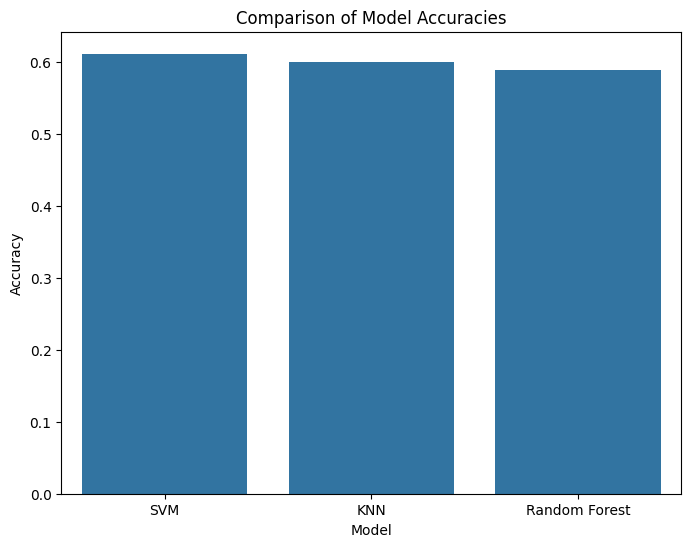

In [46]:
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

Energy, loudness, and acousticness contain overlapping information, so I kept energy and removed loudness and acousticness. Removing these correlated features did not consistently improve model performance. Some models improved slightly while others performed worse, showing that correlated features are not necessarily useless for prediction. Overall, keeping all features produced strong results for this three class classification problem.